# Generating NDVI animations

* **Products used:**
[ndvi_anomaly](https://explorer.digitalearth.africa/ndvi_anomaly)

## Background
This notebook shows how to generate an animation to visualise the NDVI across space, mean NDVI through time, and NDVI anomalies. It also generates a similar animation for monthly rainfall and rainfall anomalies.

Animations can help visualise changes in patterns through time. The visualisation of both mean values and anomalies means that seasonal and inter-annual aspects of time can be assessed. Complementing this with spatial images enhances interpretability of earth observation data.

## Description

The workflow for generating an animation progresses through the following steps:
1. Select an area of interest.
2. Load DE Africa Mean NDVI and Anomalies product.
3. Mask to cropland.
4. Generate NDVI animation.
5. Generate rainfall animation.
***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages and apps" cell.

### Load packages

In [1]:
pip install datacube deafrica-tools odc-stac pystac_client --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.1/543.1 kB 18.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.4/449.4 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.0/264.0 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
%matplotlib inline

import os
import datacube
import datetime as dt
import xarray as xr
import rioxarray
import geopandas as gpd
import dask
from odc.geo.geom import Geometry
from pystac_client import Client
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib.dates as mdates
from odc.stac import configure_rio, stac_load
from deafrica_tools.plotting import display_map
from deafrica_tools.areaofinterest import define_area
from deafrica_tools.get_config import get_product_config

### Analysis parameters


The following cell sets the parameters, which define the area of interest and the length of time to conduct the analysis over.
The parameters are

* `lat`: The central latitude to analyse (e.g. `10.338`).
* `lon`: The central longitude to analyse (e.g. `-1.055`).
* `buffer`: The number of square degrees to load around the central latitude and longitude.
For reasonable loading times, set this as `0.1` or lower.


#### Select location
To define the area of interest, there are two methods available:

1. By specifying the latitude, longitude, and buffer. This method requires you to input the central latitude, central longitude, and the buffer value in square degrees around the center point you want to analyze. For example, `lat = 10.338`, `lon = -1.055`, and `buffer = 0.1` will select an area with a radius of 0.1 square degrees around the point with coordinates (10.338, -1.055).

    Alternatively, you can provide separate buffer values for latitude and longitude for a rectangular area. For example, `lat = 10.338`, `lon = -1.055`, and `lat_buffer = 0.1` and`lon_buffer = 0.08` will select a rectangular area extending 0.1 degrees north and south, and 0.08 degrees east and west from the point `(10.338, -1.055)`.

   For reasonable loading times, set the buffer as `0.1` or lower.

2. By uploading a polygon as a `GeoJSON or Esri Shapefile`. If you choose this option, you will need to upload the geojson or ESRI shapefile into the Sandbox using Upload Files button <img align="top" src="https://github.com/digitalearthafrica/deafrica-sandbox-notebooks/blob/main/Supplementary_data/upload_files_icon.png?raw=1"> in the top left corner of the Jupyter Notebook interface. ESRI shapefiles must be uploaded with all the related files `(.cpg, .dbf, .shp, .shx)`. Once uploaded, you can use the shapefile or geojson to define the area of interest. Remember to update the code to call the file you have uploaded.

To use one of these methods, you can uncomment the relevant line of code and comment out the other one. To comment out a line, add the `"#"` symbol before the code you want to comment out. By default, the first option which defines the location using latitude, longitude, and buffer is being used.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

<Axes: >

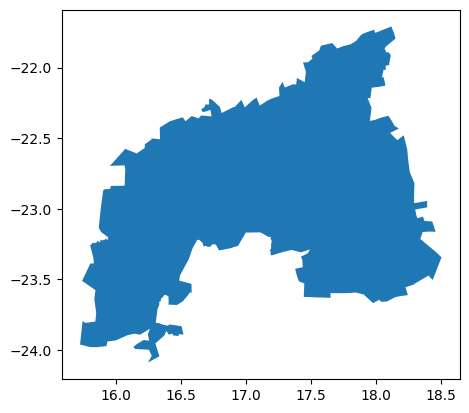

In [4]:
khomas = gpd.read_file('data/Khomas/region_khomas.shp')

khomas.plot()

In [5]:
# # Define the area of interest for the analysis
year = "2022"

# Method 1: Specify the latitude, longitude, and buffer
#aoi = define_area(lat=-17.71, lon=48.21, buffer=0.05)

# Method 2: Use a polygon as a GeoJSON or Esri Shapefile.
aoi = define_area(vector_path='data/Khomas/region_khomas.shp')

#Create a geopolygon and geodataframe of the area of interest
geopolygon = Geometry(aoi["features"][0]["geometry"], crs="epsg:4326")
geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

# Get the latitude and longitude range of the geopolygon
lat_range = (geopolygon_gdf.total_bounds[1], geopolygon_gdf.total_bounds[3])
lon_range = (geopolygon_gdf.total_bounds[0], geopolygon_gdf.total_bounds[2])

display_map(lon_range, lat_range)

We will define the start and end date as the beginning and end of our year of interest.

In [6]:
start_date = dt.datetime.strptime(year, "%Y").replace(month=1, day=1)
end_date = dt.datetime.strptime(year, "%Y").replace(month=12, day=31)

Below, the analysis parameters are used to construct a query which loads the DE Africa mean NDVI and anomalies product.

In [7]:
config = get_product_config("ndvi_anomaly", profile="deafrica")

configure_rio(
    cloud_defaults=True,
    aws={"aws_unsigned": True},
    AWS_S3_ENDPOINT="s3.af-south-1.amazonaws.com",
)

# Open the stac catalogue
catalog = Client.open("https://explorer.digitalearth.africa/stac")

collections = ["ndvi_anomaly"]

bbox = [lon_range[0], lat_range[0], lon_range[1], lat_range[1]]

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date.strftime("%Y-%m-%d")}/{end_date.strftime("%Y-%m-%d")}"
)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 192 datasets


In [8]:
crs = "EPSG:6933"
resolution = 600

ds = stac_load(
    items,
    crs=crs,
    resolution=resolution,
    chunks={},
    groupby="solar_day",
    stac_cfg=config,
    bbox=bbox,
)

# View the Xarray Dataset
ds

<xarray.Dataset> Size: 23MB
Dimensions:           (y: 468, x: 448, time: 12)
Coordinates:
  * y                 (y) float64 4kB -2.705e+06 -2.706e+06 ... -2.985e+06
  * x                 (x) float64 4kB 1.517e+06 1.518e+06 ... 1.785e+06
  * time              (time) datetime64[ns] 96B 2022-01-01 ... 2022-12-01
    spatial_ref       int32 4B 6933
Data variables:
    ndvi_mean         (time, y, x) float32 10MB dask.array<chunksize=(1, 468, 448), meta=np.ndarray>
    clear_count       (time, y, x) int8 3MB dask.array<chunksize=(1, 468, 448), meta=np.ndarray>
    ndvi_std_anomaly  (time, y, x) float32 10MB dask.array<chunksize=(1, 468, 448), meta=np.ndarray>

In [9]:
gpd.GeoDataFrame(khomas.geometry)

,geometry
0,"POLYGON ((17.17384 -23.1993, 17.10939 -23.1668..."


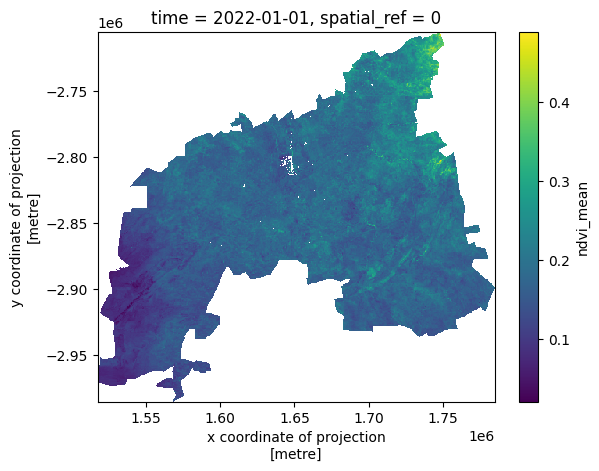

In [10]:
ds_clip = ds.rio.clip(gpd.GeoDataFrame(khomas).set_geometry('geometry').geometry.values, khomas.crs)

ds_clip.ndvi_mean.isel(time=0).plot()

### Load cropland mask

This is an optional step for masking the NDVI data to cropland. In this instance, we are interested in inspecting crop vegetation patterns only, so we use the mask to do this.

In [12]:
config = get_product_config("crop_mask", profile="deafrica")

collections = ["crop_mask"]

bbox = [lon_range[0], lat_range[0], lon_range[1], lat_range[1]]

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections)

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 16 datasets


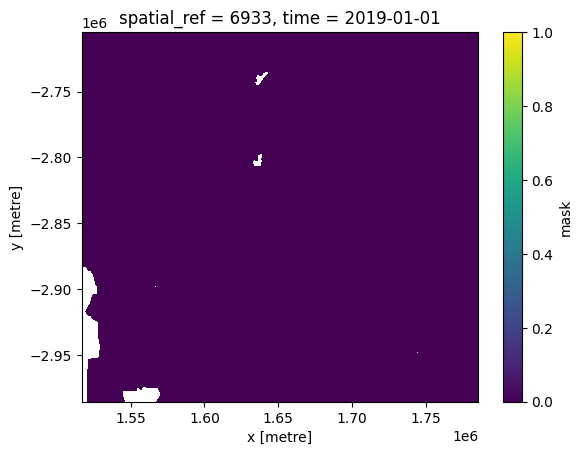

In [13]:
cm = stac_load(
    items,
    crs=crs,
    resolution=resolution,
    chunks={},
    groupby="solar_day",
    stac_cfg=config,
    bbox=bbox,
).squeeze()
cm.mask.where(cm.mask<255).plot()

### Mask NDVI to cropland

We mask the NDVI data to the cropland extent shown above.

In [ ]:
# no cropland so commenting out this step
#ds = ds.where(cm.mask ==1)

## Prepare animation data

We need to prepare three objects for the animation:
1. Mean NDVI with spatial attributes.
2. Mean NDVI through time, aggregated as an average across space.
3. NDVI anomalies for each month, aggregated as an average across space.

In [14]:
ds_mean = ds_clip.ndvi_mean

ds_mean_1D = ds_mean.mean(dim=['x', 'y'], skipna=True)

ndvi_anom = ds_clip.ndvi_std_anomaly.mean(dim=['x', 'y']).to_dataframe().drop(['spatial_ref'], axis=1)

## Run animation

To create the animation, the cell below follows a few key steps:
1. Define the layout of the three axes and their size.
2. Set axis parameters (titles etc)
3. Start each axis with the first image of the animation (Januray).
4. Define an update function which adds each month sequentially to each of the three charts.
5. Run the animation.

Note the animation renders in its own window. The bottom right toggle enables download of the animation.

In [15]:
# create a figure and axes
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(10)


ax1 = plt.subplot2grid(shape=(2, 2), loc=(0, 1), colspan=2)
ax2 = plt.subplot2grid(shape=(2, 2), loc=(0, 0), rowspan=2)
ax3 = plt.subplot2grid(shape=(2, 2), loc=(1, 1), colspan=2)

# setup starting plot
cax = ds_clip.ndvi_mean[0,:,:].plot(
    add_colorbar=True,
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    cbar_kwargs={
        'extend':'neither'
    },
    ax=ax2
)

ax1.set_ylim([0, 1])
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.set_title("Mean NDVI - Khomas")
ax1.set_xlabel("Date")
ax1.set_ylabel("NDVI")

ax3.set_ylim([-4, 4])
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax3.set_title("NDVI Anomaly - Khomas")
ax3.set_xlabel("Date")
ax3.set_ylabel("Std Deviations from monthly mean")
ax3.axhline(0, color='black', linestyle='--')

x = ds_mean_1D.time
y = ds_mean_1D

x2 = ndvi_anom.index
y2 = [0] * ndvi_anom.ndvi_std_anomaly
bars = ax3.bar(x2, y2, align='center', width=20,color=(ndvi_anom.ndvi_std_anomaly > 0).map({True: 'g', False: 'brown'}))

line, = ax1.plot(x, y, marker='*',
                color='blue')

def update(num, x, y, x2, y2, bars, line):
    y2[num] = ndvi_anom.ndvi_std_anomaly[num]
    bars[num].set_height(y2[num])
    cax.set_array(ds_clip.ndvi_mean[(num),:,:].values.flatten())
    ax2.set_title("Time = " + str(ds.ndvi_mean.coords['time'].values[(num)])[:12])
    line.set_data(x[:num+1], y[:num+1])
    return line,

plt.tight_layout()
ani = animation.FuncAnimation(fig, update, len(x), fargs=[x, y, x2, y2, bars, line],
                              interval=400, blit=False, repeat=True)
#ani.save('Khomas_ndvi_anim.gif')

plt.close()

HTML(ani.to_html5_video())

# Make an NDVI animation with rainfall

The animation above summarises cropland NDVI in space and time, within a period of interest. We can add associated information to this visualisation, such as rainfall. The next few steps demonstrate how to load rainfall data and calculate anomalies for plotting.

## Rainfall anomaly parameters

We need to set some parameters for calculating the rainfall anomaly. The `time_m` period is a baseline period while `time_x` is the year of interest.

### Load rainfall data

In [17]:
config = get_product_config("rainfall_chirps_monthly", profile="deafrica")

collections = ["rainfall_chirps_monthly"]

start_date_m = "2000-01-01"
end_date_m = "2020-12-31"

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date_m}/{end_date_m}")

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 252 datasets


In [18]:
ds_rf_m = stac_load(
    items,
    crs=crs,
    resolution=5000,
    chunks={},
    groupby="solar_day",
    stac_cfg=config,
    bbox=bbox,
)


In [19]:
start_date_m = "2022-01-01"
end_date_m = "2022-12-31"

# Build a query with the set parameters
query = catalog.search(
    bbox=bbox, collections=collections, datetime=f"{start_date_m}/{end_date_m}")

# Search the STAC catalog for all items matching the query
items = list(query.items())
print(f"Found: {len(items):d} datasets")

Found: 11 datasets


In [20]:
ds_rf_x = stac_load(
    items,
    crs=crs,
    resolution=5000,
    chunks={},
    groupby="solar_day",
    stac_cfg=config,
    bbox=bbox,
)

Below, we calculate the monthly mean rainfall and anomaly.

In [21]:
# monthly means
climatology_mean = ds_rf_m.groupby('time.month').mean('time').compute()

#calculate monthly std dev
climatology_std = ds_rf_m.groupby('time.month').std('time').compute()

stand_anomalies = xr.apply_ufunc(
    lambda x, m, s: (x - m) / s,
    ds_rf_x.groupby("time.month"),
    climatology_mean,
    climatology_std,
    output_dtypes=[ds_rf_x.rainfall.dtype],
    dask="allowed"
).compute()

### Prepare animation data

As for the NDVI animation above, we need to prepare dataframes for the rainfall animation.

In [22]:
spatial_mean_rain = ds_rf_x.rainfall.mean(['x','y'])

spatial_mean_rain.time

spatial_mean_anoms = stand_anomalies.rainfall.mean(['x','y'], skipna=True).sel(time=slice('2021-12-31', end_date)).to_dataframe().drop(
    ['spatial_ref', 'month'], axis=1).fillna(0)

## Run the animation

We follow the steps listed for the NDVI animation above to produce the rainfall animation.

In [23]:
# create a figure and axes
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(10)


ax1 = plt.subplot2grid(shape=(2, 2), loc=(0, 1), colspan=2)
ax2 = plt.subplot2grid(shape=(2, 2), loc=(0, 0), rowspan=2)
ax3 = plt.subplot2grid(shape=(2, 2), loc=(1, 1), colspan=2)

cax = ds_clip.ndvi_mean[0,:,:].plot(
    add_colorbar=True,
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    cbar_kwargs={
        'extend':'neither'
    },
    ax=ax2
)

ax1.set_title("Monthly Total Rainfall - Khomas")
ax1.set_xlabel("Date")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.set_ylabel("Monthly Rainfall (mm)")

ax3.clear()
ax3.set_ylim([-4, 4])
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax3.set_title("Rainfall Anomaly - Khomas")
ax3.set_xlabel("Date")
ax3.set_ylabel("Std Deviations from monthly mean")
ax3.axhline(0, color='black', linestyle='--')

def update(num, x, y, line):
    y2.iloc[num] =  spatial_mean_anoms.rainfall.iloc[num]
    bars[num].set_height(y2.iloc[num])
    cax.set_array(ds_clip.ndvi_mean[(num),:,:].values.flatten())
    ax2.set_title("Time = " + str(ds.ndvi_mean.coords['time'].values[(num)])[:12])
    line.set_data(x[:num+1], y[:num+1])
    return line,

x = spatial_mean_rain.time
y = spatial_mean_rain

x2 = spatial_mean_anoms.index
y2 = [0] * spatial_mean_anoms.rainfall
bars = ax3.bar(x2, y2, align='center', width=20,color=(spatial_mean_anoms.rainfall > 0).map({True: 'b', False: 'r'}))

line, = ax1.plot(x, y, marker='*',
                color='blue')
plt.tight_layout()
ani = animation.FuncAnimation(fig, update, len(x), fargs=[x, y, line],
                              interval=400, blit=True)
ani.save('Khomas_rainall_anim.gif')
plt.close()

#HTML(ani.to_html5_video())

## Drawing conclusions

The animations enable us to inspect how vegetation changes within a year, and by showing anomalies, how the year of interest compares to a historical baseline.

This kind of analysis can assist in assessment of crop production in a given year, and can feed into early warning systems and forecasts on crop production and food security.

---

## Additional information

<b> License </b> The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0).

Digital Earth Africa data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

<b> Contact </b> If you need assistance, please post a question on the [DE Africa Slack channel](https://digitalearthafrica.slack.com/) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).

If you would like to report an issue with this notebook, you can file one on [Github](https://github.com/digitalearthafrica/deafrica-sandbox-notebooks).

<b> Compatible datacube version </b>

In [24]:
print(datacube.__version__)

1.9.10


**Last Tested:**

In [25]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-10-31'